In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
df = pd.read_csv("RDDT.csv")
print(df.head())
print(df.info()) 
print(df.describe()) 


         Date       Open       High        Low      Close  Adj Close    Volume
0  2024-03-22  48.880001  51.000000  45.340000  46.000000  46.000000  15936700
1  2024-03-25  47.090000  61.939999  46.080002  59.799999  59.799999  24398800
2  2024-03-26  67.709999  74.900002  63.209999  65.110001  65.110001  35331000
3  2024-03-27  63.759998  63.759998  55.619999  57.750000  57.750000  18758300
4  2024-03-28  54.520000  55.299999  49.099998  49.320000  49.320000  12608100
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       36 non-null     object 
 1   Open       36 non-null     float64
 2   High       36 non-null     float64
 3   Low        36 non-null     float64
 4   Close      36 non-null     float64
 5   Adj Close  36 non-null     float64
 6   Volume     36 non-null     int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 2.1+ KB
No

In [6]:
print(df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


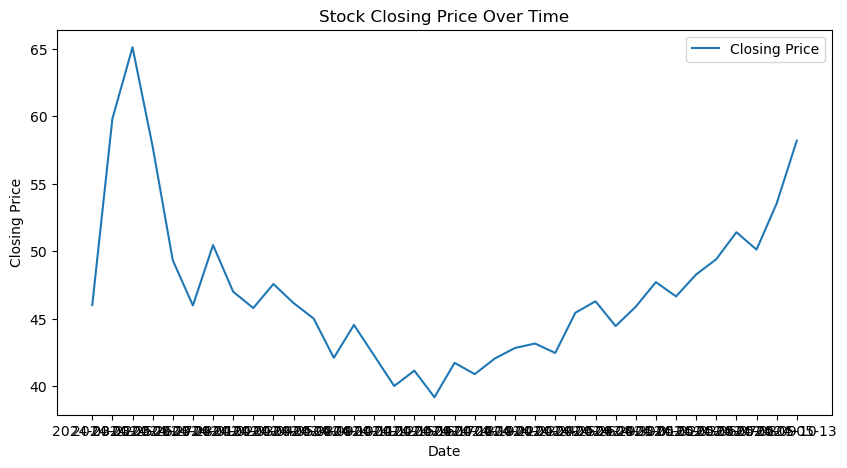

In [8]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'], label='Closing Price')
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Stock Closing Price Over Time")
plt.legend()
plt.show()

In [10]:
df['Date'] = pd.to_datetime(df['Date'])
df['Days'] = (df['Date'] - df['Date'].min()).dt.days

X = df[['Days']]
y = df['Close']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Regression

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

Mean Absolute Error: 5.258595750556195
Mean Squared Error: 41.127225437874536
Root Mean Squared Error: 6.4130511800448415


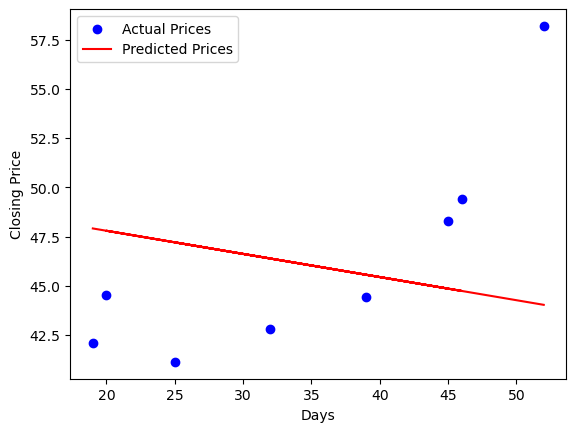

In [22]:
plt.scatter(X_test, y_test, color="blue", label="Actual Prices")
plt.plot(X_test, y_pred, color="red", label="Predicted Prices")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

In [24]:
future_days = pd.DataFrame({'Days': range(df['Days'].max() + 1, df['Days'].max() + 31)})


In [26]:
future_predictions = model.predict(future_days)

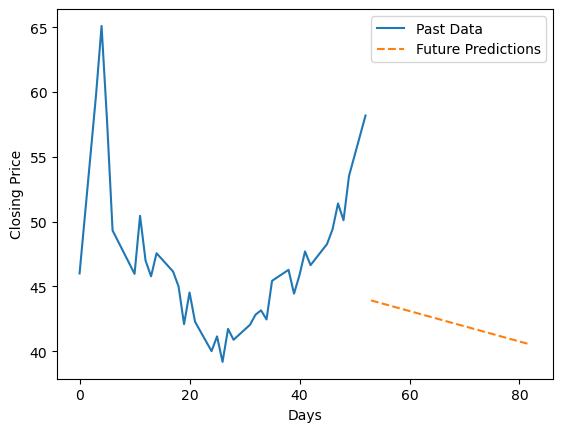

In [28]:
plt.plot(df['Days'], df['Close'], label='Past Data')
plt.plot(future_days, future_predictions, label='Future Predictions', linestyle='dashed')
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

In [30]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)


rf_model.fit(X_train, y_train)


future_predictions_rf = rf_model.predict(future_days)


print(future_predictions_rf)


[51.70509979 51.70509979 51.70509979 51.70509979 51.70509979 51.70509979
 51.70509979 51.70509979 51.70509979 51.70509979 51.70509979 51.70509979
 51.70509979 51.70509979 51.70509979 51.70509979 51.70509979 51.70509979
 51.70509979 51.70509979 51.70509979 51.70509979 51.70509979 51.70509979
 51.70509979 51.70509979 51.70509979 51.70509979 51.70509979 51.70509979]


In [32]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)
rf_model.fit(X_train, y_train)
future_predictions_rf = rf_model.predict(future_days)

In [34]:
df['MA7'] = df['Close'].rolling(window=7).mean()
df['MA14'] = df['Close'].rolling(window=14).mean()


In [36]:
df['Prev_Day'] = df['Close'].shift(1)
df['Prev_Day'].fillna(df['Prev_Day'].median(), inplace=True) 

C:\Users\pelin\AppData\Local\Temp\ipykernel_16212\3670034574.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Prev_Day'].fillna(df['Prev_Day'].median(), inplace=True)


In [38]:
df['Price_Change'] = df['Close'].pct_change()
df['Price_Change'].fillna(0, inplace=True)  

C:\Users\pelin\AppData\Local\Temp\ipykernel_16212\2940027323.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price_Change'].fillna(0, inplace=True)


Random Forest Regressor

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

features = ['Days', 'MA7', 'MA14', 'Prev_Day', 'Price_Change']
X = df[features]
y = df['Close']


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [44]:
future_days = np.array(range(df['Days'].max() + 1, df['Days'].max() + 31)).reshape(-1, 1)
future_df = pd.DataFrame({'Days': future_days.flatten()})

In [46]:
future_df['MA7'] = df['Close'].rolling(window=7).mean().iloc[-1]
future_df['MA14'] = df['Close'].rolling(window=14).mean().iloc[-1]
future_df['Prev_Day'] = df['Close'].iloc[-1]
future_df['Price_Change'] = df['Price_Change'].iloc[-1]

future_predictions = model.predict(future_df)

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [50]:
rf = RandomForestRegressor(random_state=42)
rf_search = RandomizedSearchCV(rf, param_grid, n_iter=20, cv=5, scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 300]},
                   random_state=42, scoring='neg_mean_absolute_error')

In [52]:
print("Best parameters:", rf_search.best_params_)

best_rf = rf_search.best_estimator_
best_rf.fit(X_train, y_train)

y_pred_optimized = best_rf.predict(X_test)


Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}


In [54]:
mae = mean_absolute_error(y_test, y_pred_optimized)
mse = mean_squared_error(y_test, y_pred_optimized)
rmse = np.sqrt(mse)

print("Optimized Random Forest - Mean Absolute Error:", mae)
print("Optimized Random Forest - Mean Squared Error:", mse)
print("Optimized Random Forest - Root Mean Squared Error:", rmse)

Optimized Random Forest - Mean Absolute Error: 2.1037482303584616
Optimized Random Forest - Mean Squared Error: 6.598020674977963
Optimized Random Forest - Root Mean Squared Error: 2.5686612612366706


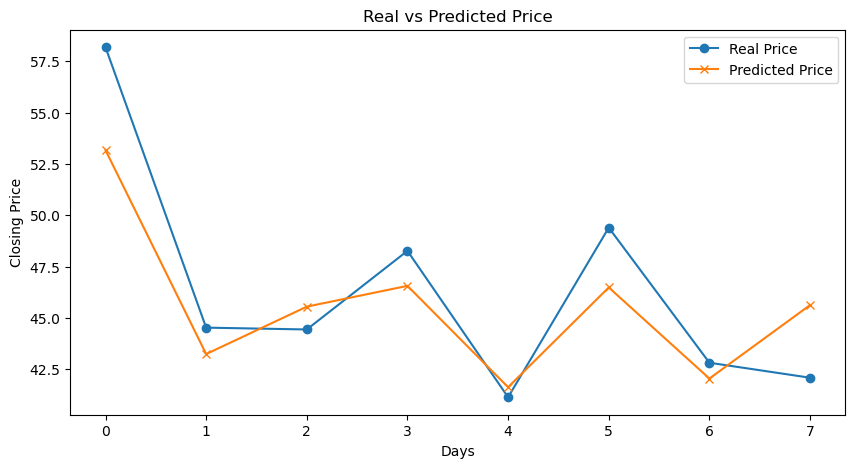

In [56]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Real Price", marker='o')
plt.plot(y_pred_optimized, label="Predicted Price", marker='x')
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.title("Real vs Predicted Price")
plt.legend()
plt.show()

In [58]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')

cv_scores = np.abs(cv_scores)

print(f"Cross-validation MAE scores: {cv_scores}")
print(f"Mean MAE: {cv_scores.mean():.2f}")
print(f"Standard Deviation: {cv_scores.std():.2f}")


Cross-validation MAE scores: [6.00933712 2.15924329 2.96685777 1.32038628 4.84282833]
Mean MAE: 3.46
Standard Deviation: 1.73


Initial Model:Linear Regression:
I started with a Linear Regression model to predict stock prices. However,the model did not fit the real data well, resulting in relatively high error rate.
To improve prediction accuracy, I experimented with Random Forest Regressor; which performed best in terms of error reduction and stability. 
Cross Validation and Evaluation:
To validate the model's performance, I used cross-validation(5-fold)
The scores were:
Cross-validation MAE scores: [6.00933712 2.15924329 2.96685777 1.32038628 4.84282833]
Mean MAE: 3.46
Standard Deviation: 1.
This indicates that my model is stable and performs well on different data splits. 
My final model achieves reasonable accuracy with a low error rate. If further improvements are needed, we could explore:
-more complex models
-feature engineering
-collecting more historical data for training 
Conclusion: Random Forest Regressor model provides reliable price predictions with an acceptable error margin73